# Random Forest Regressor — Reem

This notebook trains and evaluates a Random Forest Regressor on the Medical Insurance dataset.

In [1]:
import pandas as pd
from pathlib import Path
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from joblib import dump
import os

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import learning_curve
from sklearn.inspection import permutation_importance

PLOTS_DIR = (Path.cwd().parent / "EDA")
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

def plot_pred_vs_actual(y_true, y_pred, title, fname):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, s=12, alpha=0.6)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, "--")
    plt.xlim(lims); plt.ylim(lims)
    plt.xlabel("Actual charges"); plt.ylabel("Predicted charges")
    plt.title(title)
    plt.tight_layout(); plt.savefig(PLOTS_DIR / fname, dpi=150); plt.show()

def plot_residuals(y_true, y_pred, title, fname):
    resid = y_true - y_pred
    plt.figure(figsize=(6,3.8))
    plt.scatter(y_pred, resid, s=12, alpha=0.6)
    plt.axhline(0, color="k", linestyle="--", linewidth=1)
    plt.xlabel("Predicted charges"); plt.ylabel("Residual (y - ŷ)")
    plt.title(title)
    plt.tight_layout(); plt.savefig(PLOTS_DIR / fname, dpi=150); plt.show()

def plot_residual_hist(y_true, y_pred, title, fname):
    resid = y_true - y_pred
    plt.figure(figsize=(6,3.8))
    plt.hist(resid, bins=30)
    plt.title(title); plt.xlabel("Residual"); plt.ylabel("Count")
    plt.tight_layout(); plt.savefig(PLOTS_DIR / fname, dpi=150); plt.show()

def plot_learning_curve(estimator, X, y, title, fname):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1, shuffle=True, random_state=42
    )
    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -test_scores.mean(axis=1)
    plt.figure(figsize=(6,3.8))
    plt.plot(train_sizes, train_rmse, marker="o", label="Train RMSE")
    plt.plot(train_sizes, val_rmse, marker="o", label="CV RMSE")
    plt.xlabel("Training examples"); plt.ylabel("RMSE")
    plt.title(title); plt.legend()
    plt.tight_layout(); plt.savefig(PLOTS_DIR / fname, dpi=150); plt.show()

def get_feature_names_from_pipe(pipe):
    return pipe.named_steps["prep"].get_feature_names_out()

In [3]:
DATA_PATH = Path.cwd().parent / "insurance.csv"
print("Reading:", DATA_PATH.resolve())
df = pd.read_csv(DATA_PATH)
df.head()

Reading: /Users/abdulmohsenalmunayes/Projects/insurance-ml-project/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
X = df.drop(columns=["charges"])
y = df["charges"]

categorical = ["sex", "smoker", "region"]
preprocess = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), categorical)],
    remainder="passthrough"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline([("prep", preprocess), ("model", model)])
pipe.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [6]:
y_pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

MAE:  2530.36
RMSE: 4621.20
R²:   0.862


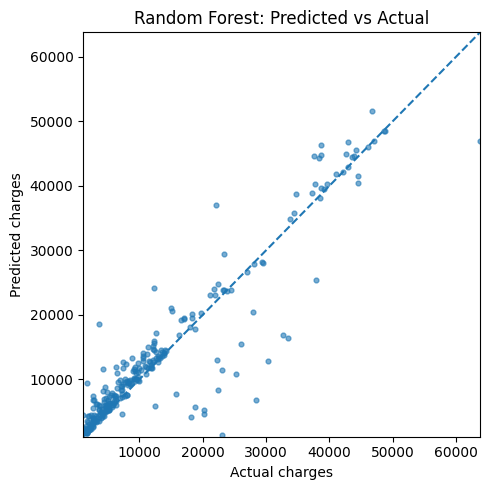

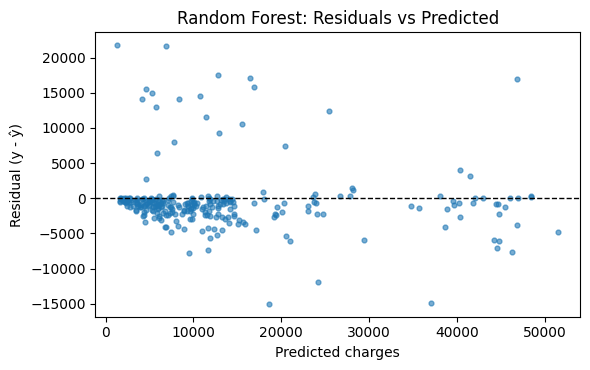

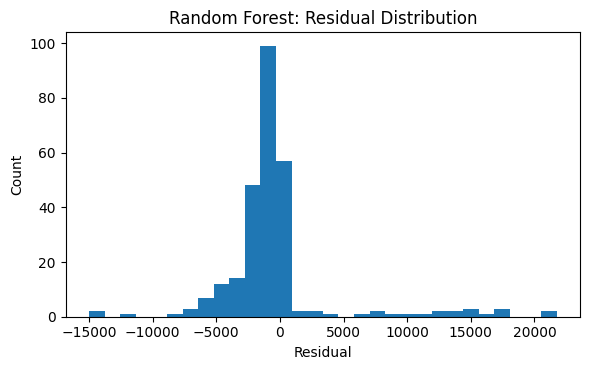

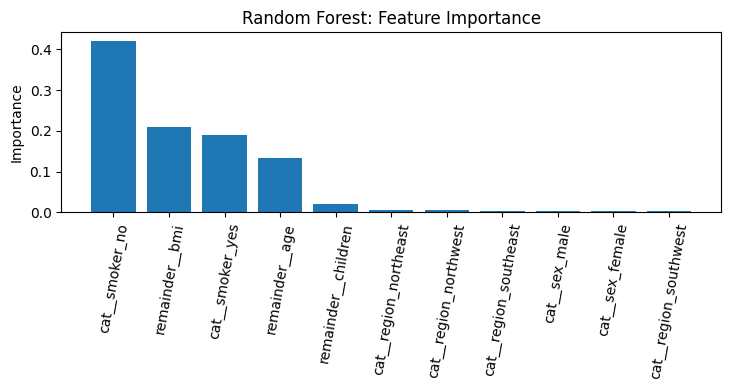

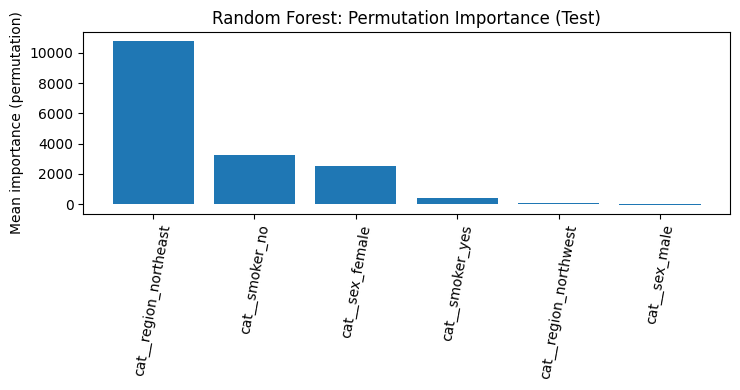

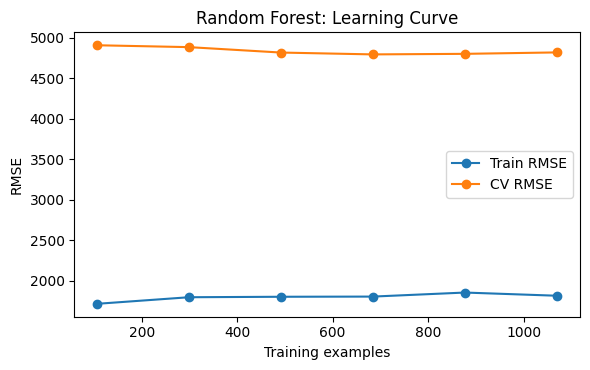

In [7]:
# 1) Predicted vs Actual + residuals
plot_pred_vs_actual(y_test, y_pred, "Random Forest: Predicted vs Actual", "rf_pred_vs_actual.png")
plot_residuals(y_test, y_pred, "Random Forest: Residuals vs Predicted", "rf_residuals_scatter.png")
plot_residual_hist(y_test, y_pred, "Random Forest: Residual Distribution", "rf_residual_hist.png")

# 2) Feature importance (Gini / impurity-based) + permutation as a check
fn = get_feature_names_from_pipe(pipe)
try:
    imp = pipe.named_steps["model"].feature_importances_
    order = np.argsort(imp)[::-1]
    plt.figure(figsize=(7.5,4))
    plt.bar(range(len(imp)), imp[order])
    plt.xticks(range(len(imp)), fn[order], rotation=80)
    plt.ylabel("Importance")
    plt.title("Random Forest: Feature Importance")
    plt.tight_layout(); plt.savefig(PLOTS_DIR / "rf_importance.png", dpi=150); plt.show()
except Exception:
    pass

r = permutation_importance(pipe, X_test, y_test, n_repeats=15, random_state=42, n_jobs=-1, scoring="neg_root_mean_squared_error")
fi = r.importances_mean
order = np.argsort(fi)[::-1]
plt.figure(figsize=(7.5,4))
plt.bar(range(len(fi)), fi[order])
plt.xticks(range(len(fi)), fn[order], rotation=80)
plt.ylabel("Mean importance (permutation)")
plt.title("Random Forest: Permutation Importance (Test)")
plt.tight_layout(); plt.savefig(PLOTS_DIR / "rf_perm_importance.png", dpi=150); plt.show()

# 3) Learning curve
plot_learning_curve(pipe, X, y, "Random Forest: Learning Curve", "rf_learning_curve.png")

In [8]:
MODELS_DIR = Path.cwd().parent / "models"
os.makedirs(MODELS_DIR, exist_ok=True)

dump(pipe, MODELS_DIR / "random_forest_regressor.joblib")
pd.DataFrame([{
    "Model": "RandomForestRegressor",
    "MAE": mae, "RMSE": rmse, "R2": r2
}]).to_csv(MODELS_DIR / "random_forest_regressor_metrics.csv", index=False)

MODELS_DIR, list(MODELS_DIR.glob("random_forest_regressor*"))

(PosixPath('/Users/abdulmohsenalmunayes/Projects/insurance-ml-project/models'),
 [PosixPath('/Users/abdulmohsenalmunayes/Projects/insurance-ml-project/models/random_forest_regressor.joblib'),
  PosixPath('/Users/abdulmohsenalmunayes/Projects/insurance-ml-project/models/random_forest_regressor_metrics.csv')])